# Twitter Sentiment Analysis using NLP

In [1]:
!pip install wordcloud

## Project Overview
This project performs sentiment analysis on tweets using Natural Language Processing (NLP) techniques. 
The objective is to classify tweets into Positive, Negative, and Neutral categories. 
Text preprocessing, TF-IDF vectorization, and Logistic Regression are used to build the sentiment classification model.

## Import All Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\seema\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset
##### The Twitter sentiment dataset is loaded into a pandas DataFrame for further analysis and preprocessing.

In [3]:
df = pd.read_csv("twitter_training.csv", header=None)

df.head() 

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


### Add Column Names

In [4]:
df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Content']

df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


### Keep Important Columns Only

In [5]:
df = df[['Sentiment', 'Tweet_Content']]

df.head()

,Sentiment,Tweet_Content
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


### Check Sentiment Labels and Remove Irrelevant Tweets

In [6]:
df['Sentiment'].value_counts()


Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [7]:
df = df[df['Sentiment'] != 'Irrelevant']

In [8]:
df['Sentiment'].value_counts()

Sentiment
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64

## Data Cleaning and Validation

##### This step checks for missing values, removes incomplete records, and verifies the dataset dimensions to ensure that the data is clean and ready for further preprocessing and analysis.

In [9]:
df.isnull().sum()

Sentiment          0
Tweet_Content    571
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
Index: 61121 entries, 0 to 74681
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sentiment      61121 non-null  object
 1   Tweet_Content  61121 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB


,Sentiment,Tweet_Content
941,Neutral,Sky Lines > SuperBadass And Goliath. Borderlan...
32460,Positive,League's best theme by FAR
48148,Negative,@HomeDepot. 5 This has been the WORST biggest ...
12200,Negative,@ N2K did you fucking retards use your brains ...
64888,Negative,Madden began ruining out the game. 29 These du...


## Preserve Important Negation Words

##### The English stopwords are loaded for text preprocessing. However, important negation words such as "not", "no", and "never" are retained because they significantly affect the sentiment of a tweet and help improve model accuracy.

In [12]:
stop_words = set(stopwords.words('english'))

stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('never')

## Text Preprocessing

##### Raw tweets often contain URLs, special characters, stopwords, emojis, and unnecessary text. 
##### Therefore, preprocessing is performed to clean the tweets and improve model performance.

In [13]:
def clean_tweet(text):

    # convert to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation/special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = text.strip()

    # remove stopwords
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [14]:
df['Clean_Tweet'] = df['Tweet_Content'].apply(clean_tweet)

In [15]:
df[['Tweet_Content', 'Clean_Tweet']].head()

,Tweet_Content,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,I am coming to the borders and I will kill you...,coming borders kill
2,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,im coming on borderlands and i will murder you...,im coming borderlands murder
4,im getting on borderlands 2 and i will murder ...,im getting borderlands murder


In [16]:
df['Clean_Tweet'].replace('', np.nan, inplace=True)

df.dropna(subset=['Clean_Tweet'], inplace=True)

C:\Users\seema\AppData\Local\Temp\ipykernel_5364\2545889271.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Clean_Tweet'].replace('', np.nan, inplace=True)


In [17]:
df.shape

(59702, 3)

## Exploratory Data Analysis (EDA)
##### Exploratory Data Analysis helps understand the distribution of sentiments and identify patterns in the dataset before model training.


In [18]:
df['Sentiment'].value_counts()

Sentiment
Negative    21903
Positive    20156
Neutral     17643
Name: count, dtype: int64

### Plot Sentiment Count Graph

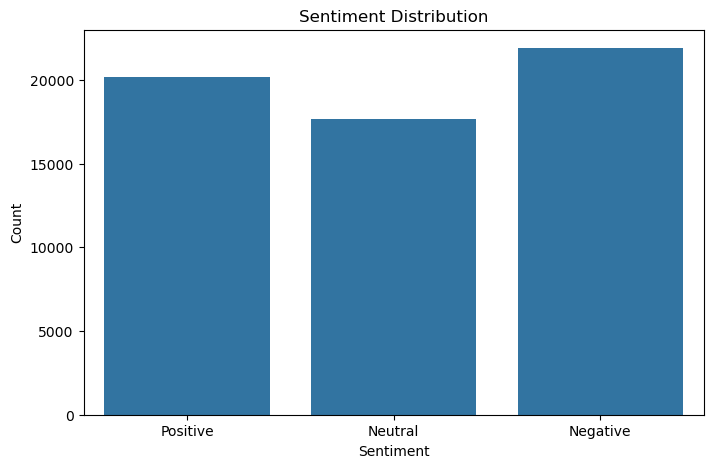

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## WordCloud Analysis
##### WordClouds are generated to visualize the most frequent words appearing in Positive, Negative, and Neutral tweets.

### Import Wordcloud

In [21]:
from wordcloud import WordCloud

### Create Positive Tweets Text

In [ ]:
positive_tweets = " ".join(
    df[df['Sentiment'] == 'Positive']['Clean_Tweet']
)

### Generate Positive WordCloud

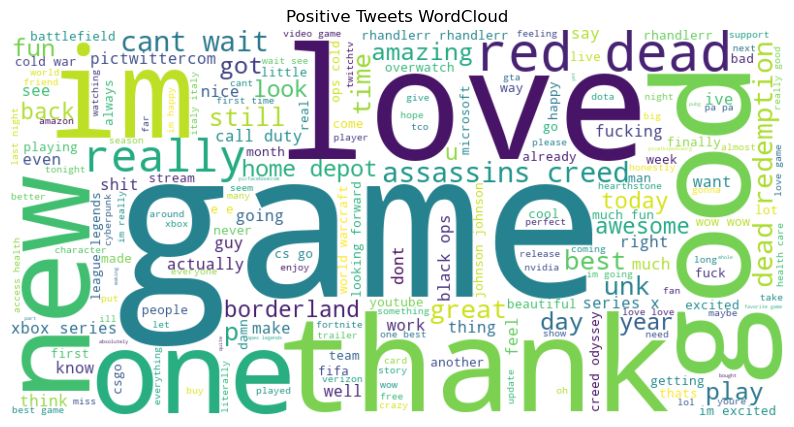

In [22]:
plt.figure(figsize=(10,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_tweets)

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Positive Tweets WordCloud")

plt.show()

### Create Negative Tweets Text

In [23]:
negative_tweets = " ".join(
    df[df['Sentiment'] == 'Negative']['Clean_Tweet']
)

### Generate Negative WordCloud

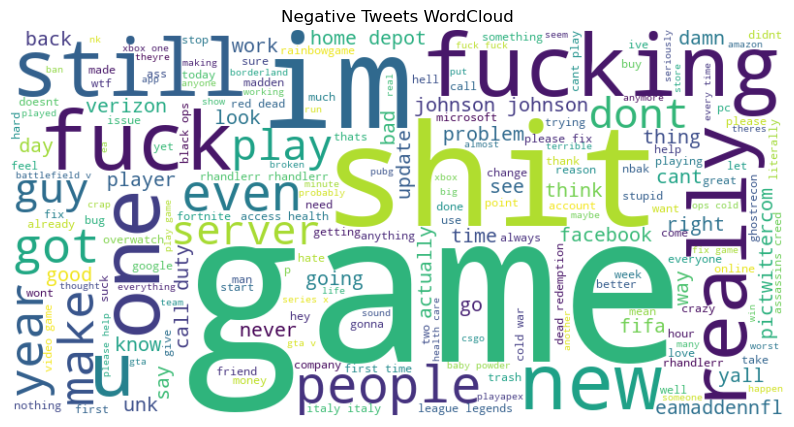

In [24]:
plt.figure(figsize=(10,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_tweets)

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Negative Tweets WordCloud")

plt.show()

### Create Neutral Tweets Text

In [25]:
neutral_tweets = " ".join(
    df[df['Sentiment'] == 'Neutral']['Clean_Tweet']
)

### Generate Neutal WordCloud

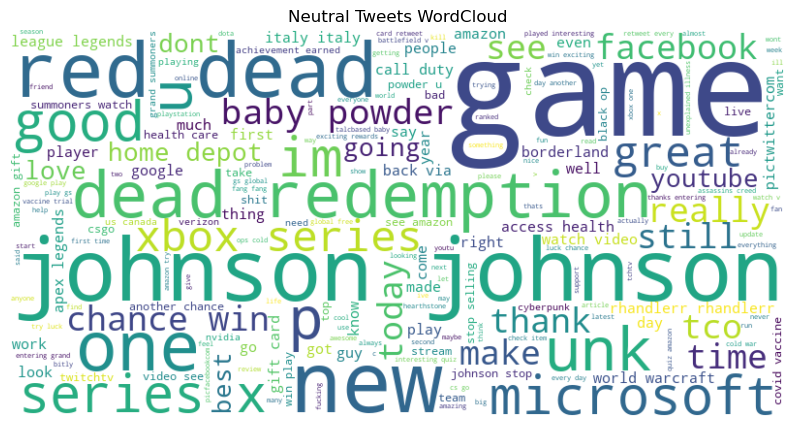

In [26]:
plt.figure(figsize=(10,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_tweets)

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Neutral Tweets WordCloud")

plt.show()

### Import Counter and Find Most Common Words

In [27]:
from collections import Counter

### Positive Common Words

In [28]:
positive_words = positive_tweets.split()

common_words = Counter(positive_words).most_common(10)

common_words

[('game', 2276),
 ('love', 1777),
 ('im', 1770),
 ('good', 1616),
 ('like', 1359),
 ('really', 1290),
 ('new', 1199),
 ('not', 1122),
 ('best', 1112),
 ('one', 1058)]

### Convert Into DataFrame

In [29]:
common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

common_df

,Word,Frequency
0,game,2276
1,love,1777
2,im,1770
3,good,1616
4,like,1359
5,really,1290
6,new,1199
7,not,1122
8,best,1112
9,one,1058


### Plot Common Words

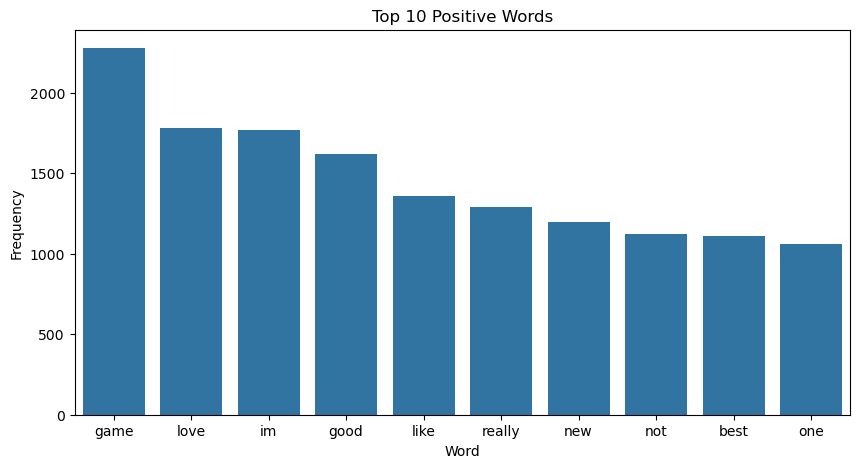

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Word',
    y='Frequency',
    data=common_df
)

plt.title("Top 10 Positive Words")

plt.show()

## Feature Engineering
##### The cleaned tweet text is used as the feature (X), while sentiment labels are used as the target variable (y).

In [31]:
X = df['Clean_Tweet']
y = df['Sentiment']

### Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Check Shapes

In [33]:
print(X_train.shape)
print(X_test.shape)

(47761,)
(11941,)


## TF-IDF Vectorization
##### Machine Learning algorithms cannot understand raw text directly. Therefore, TF-IDF is used to convert text into numerical feature vectors.

In [34]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

### Fit and Transform Training Data

In [35]:
X_train_tfidf = tfidf.fit_transform(X_train)

### Transform Test Data

In [36]:
X_test_tfidf = tfidf.transform(X_test)

### Check Shapes

In [37]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(47761, 10000)
(11941, 10000)


### View Sample Features

In [38]:
print(tfidf.get_feature_names_out()[:20])

['aaa' 'aaron' 'ab' 'abandon' 'abandon sanction' 'abandoned' 'abilities'
 'ability' 'able' 'able even' 'able go' 'able load' 'able play' 'abnormal'
 'aboard' 'absolute' 'absolute best' 'absolute shit' 'absolutely'
 'absolutely everything']


## Model Training
##### Logistic Regression is used as the classification algorithm because it performs efficiently on text classification tasks and provides strong baseline performance.

In [39]:
model = LogisticRegression(
    max_iter=1000
)

### Train the Model

In [56]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

### Make Predictions

In [41]:
y_pred = model.predict(X_test_tfidf)

## Model Evaluation
##### The trained model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score.

### Calculate Accuracy

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8011054350556904


### Display Accuracy as Percentage

In [43]:
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 80.11%


### Test Custom Tweets

In [44]:
sample_tweets = [
    "I love this game",
    "This update is terrible",
    "The game is okay"
]

### Convert to TF-IDF

In [45]:
sample_vectors = tfidf.transform(sample_tweets)

### Make Predictions 

In [46]:
predictions = model.predict(sample_vectors)

for tweet, sentiment in zip(sample_tweets, predictions):
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment: {sentiment}")
    print()

Tweet: I love this game
Predicted Sentiment: Positive

Tweet: This update is terrible
Predicted Sentiment: Negative

Tweet: The game is okay
Predicted Sentiment: Negative



### Confusion Matrix
##### The confusion matrix helps visualize the number of correct and incorrect predictions made by the model for each sentiment class.

In [47]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3703  321  308]
 [ 457 2575  476]
 [ 379  434 3288]]


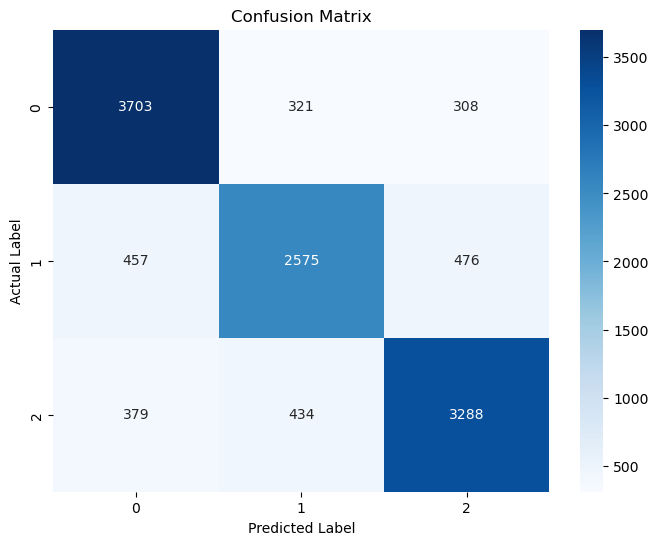

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

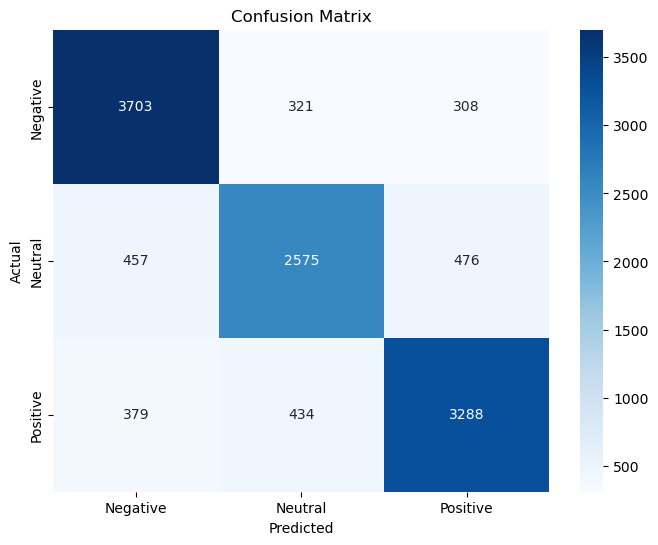

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Classification Report
##### The classification report provides Precision, Recall, and F1-score metrics for each sentiment class.

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.82      0.85      0.83      4332
     Neutral       0.77      0.73      0.75      3508
    Positive       0.81      0.80      0.80      4101

    accuracy                           0.80     11941
   macro avg       0.80      0.80      0.80     11941
weighted avg       0.80      0.80      0.80     11941



## Model Serialization
##### The trained model and TF-IDF vectorizer are saved using Pickle so they can be reused without retraining.

### Save the Trained Model

In [51]:
import pickle

with open('sentiment_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


### Save TF-IDF Vectorizer

In [52]:
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


### Load Model Again (Testing)

In [53]:
with open('sentiment_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('tfidf_vectorizer.pkl', 'rb') as file:
    loaded_tfidf = pickle.load(file)

## Testing on New Tweets
##### The saved model is tested on unseen tweets to verify its real-world prediction capability.

In [54]:
new_tweets = [
    "I absolutely love this game",
    "This update is terrible",
    "The game is okay"
]

new_tweets_vectorized = loaded_tfidf.transform(new_tweets)

predictions = loaded_model.predict(new_tweets_vectorized)

for tweet, sentiment in zip(new_tweets, predictions):
    print("Tweet:", tweet)
    print("Predicted Sentiment:", sentiment)
    print()

Tweet: I absolutely love this game
Predicted Sentiment: Positive

Tweet: This update is terrible
Predicted Sentiment: Negative

Tweet: The game is okay
Predicted Sentiment: Negative



## Final Results

##### Model Used: Logistic Regression
##### Feature Extraction: TF-IDF Vectorization
##### Dataset: Twitter Sentiment Dataset
##### Sentiment Classes: Positive, Negative, Neutral
##### Final Accuracy: 80.05%

## Conclusion

##### This project successfully implemented a Twitter Sentiment Analysis system using Natural Language Processing techniques. Tweets were cleaned through preprocessing, converted into numerical features using TF-IDF Vectorization, and classified using Logistic Regression.

##### After optimizing preprocessing and TF-IDF settings, the model achieved an accuracy of 80.05%. The model can effectively classify tweets into Positive, Negative, and Neutral categories.

##### This project demonstrates the practical application of NLP and Machine Learning techniques for text classification tasks.